# Pipeline de Sincronizacion de Señales Neurofisiológicas

**Autor:** Ignacio Negrete Silva   

---

### Propósito de este documento

Este notebook documenta el pipeline de preprocesamiento implementado sobre el dataset multimodal del proyecto Fondecyt 1231122.


**El notebook NO está pensado para ejecutarse directamente.**
Todas las figuras ya están renderizadas con datos reales de la cohorte.
El código mostrado es el código real utilizado, simplificado para claridad ilustrativa.

### Señales procesadas

| Señal | Dispositivo | Fs | Output |
|---|---|---|---|
| EEG | OpenBCI Cyton+Daisy | 125 Hz | 16 canales limpios + timestamp |
| GSR / EDA | Tobii Pro (integrado) | ~60 Hz (8 Hz efectivos) | SCL + SCR descompuestos |
| Pupilometría | Tobii Pro (integrado) | 60 Hz | Diámetro interpolado, normalizado |
| Eye Tracking | Tobii Pro (integrado) | 60 Hz | Fijaciones y sacadas por evento |

### Dependencias principales

```
mne >= 1.6          # Procesamiento EEG
mne-icalabel >= 0.4 # Clasificación automática de componentes ICA
cvxpy + cvxeda      # Descomposición GSR tónico/fásico
scipy               # Interpolación spline, estadísticas
pandas              # Manejo de datos tabulares
pyarrow             # Formato Parquet
numpy               # Operaciones numéricas
```


---
## 0. Decisiones de diseño — leer antes del código

Antes de entrar al código hay tres decisiones arquitectónicas que determinan todo lo que sigue.
Si no se entienden estas decisiones, el resto del pipeline puede parecer arbitrario.

### 0.1 Por qué Parquet y no CSV

Cada señal procesada se guarda en formato **Apache Parquet** en lugar de CSV.
Parquet preserva los tipos de datos (datetime64, float32, etc.) sin conversión, comprime entre 3-10x mejor que CSV para datos numéricos,
y permite lectura selectiva de columnas sin cargar todo el archivo. Para un dataset de 46 participantes con señales a 125 Hz,
esto hace una diferencia concreta en tiempo de carga.

```python
# Guardar
df.to_parquet('data/processed/eeg/P1.parquet', index=False)

# Cargar — tan simple como un CSV
df = pd.read_parquet('data/processed/eeg/P1.parquet')
```

Si trabajas en Colab y no tienes experiencia con Parquet, instala `pyarrow` y úsalo exactamente igual que un CSV.
No necesitas saber nada más sobre el formato.

### 0.2 Por qué EEG y Tobii van por pipelines separados

El EEG (OpenBCI) y el Tobii Pro son **dispositivos con relojes independientes**.
No se puede asumir que sus timestamps están alineados — de hecho, el EEG empieza a grabar entre 20 y 60 segundos antes que el Tobii,
y sus relojes de cristal de cuarzo tienen pequeñas diferencias de frecuencia que se acumulan durante la sesión.

Por eso el pipeline tiene tres etapas separadas: procesar EEG, procesar Tobii, y luego sincronizar ambos.
GSR, pupilometría y eye tracking comparten pipeline porque vienen **del mismo dispositivo Tobii Pro** y ya están alineados por hardware.

### 0.3 Por qué las frecuencias de muestreo NO se homogenizan

Al final del pipeline, el EEG sigue a **125 Hz** y el Tobii sigue a **60 Hz**.
Para la misma ventana temporal de 10 segundos, un epoch EEG tiene 1337 muestras y uno Tobii tiene 642 muestras.
Esto es intencional: homogenizar (resamplear el EEG a 60 Hz) implica pérdida de información.
Los modelos de aprendizaje automático que vendrán después usarán encoders separados por modalidad,
cada uno operando sobre la señal a su frecuencia nativa.


---
## 1. Ingesta de datos

### 1.1 EEG — OpenBCI

El OpenBCI genera un archivo `.txt` por sesión de grabación. Tiene un encabezado de metadatos delimitado por `%` seguido de los datos tabulares.
El archivo contiene 33 columnas: 16 canales EEG, 3 canales de acelerómetro, columnas auxiliares sin información útil, un índice de muestra y timestamps.

**Solo se preservan:** los 16 canales EEG y el timestamp formateado (necesario para la sincronización posterior).


In [ ]:
import pandas as pd
from pathlib import Path

def load_eeg_file(filepath: Path) -> pd.DataFrame:
    """Carga un archivo .txt de OpenBCI y lo convierte a DataFrame."""
    # comment='%' hace que pandas ignore las líneas del encabezado
    df = pd.read_csv(filepath, comment='%')
    return df

# El resultado: un DataFrame con 33 columnas
# Solo nos quedan los 16 canales EEG + ' Timestamp (Formatted)'
df = load_eeg_file(Path('data/raw/eeg/OpenBCISession_P1/OpenBCISession_P1.txt'))
print(df.shape)  # → (n_muestras, 33)
print(df[' Timestamp (Formatted)'].iloc[0])  # → '2025-08-08 12:21:50.138'

# Guardar como Parquet — uno por sesión
df.to_parquet('data/interim/eeg/OpenBCISession_P1.parquet', index=False)

### 1.2 Tobii Pro — GSR + Eye Tracking + Pupilometría

El Tobii Pro Lab exporta **todos los participantes en un único archivo TSV** de ~2.9 millones de filas y 99 columnas.
La primera operación es separarlo en un archivo Parquet por participante.


In [ ]:
def split_tobii_by_participant(raw_file: Path, output_dir: Path):
    """Divide el TSV unificado en un Parquet por participante."""
    df = pd.read_csv(raw_file, sep='\t')

    for participant in df['Participant name'].unique():
        df_p = df[df['Participant name'] == participant]
        safe_name = str(participant).replace(' ', '_')
        df_p.to_parquet(output_dir / f'{safe_name}.parquet', index=False)

# Resultado: data/interim/tobii/P1.parquet, P2.parquet, ...
# Columnas relevantes que usaremos:
# 'Galvanic skin response (GSR)'   → señal GSR en µS
# 'Pupil diameter filtered'        → diámetro pupilar suavizado por Tobii (mm)
# 'Eye movement type'              → Fixation | Saccade | EyesNotFound | Unclassified
# 'Recording date' + 'Recording start time' + 'Recording timestamp' → timestamps
# 'Event' + 'Event value'          → marcadores de estímulo (ImageStimulusStart, etc.)

---
## 2. Preprocesamiento EEG

El preprocesamiento EEG se implementó con **MNE-Python**.
El pipeline sigue el orden: **Notch → Bandpass → CAR → ICA → ICLabel**.
Este orden no es arbitrario — cada paso condiciona la correcta ejecución del siguiente.

### 2.1 Mapeo de canales

Los 16 canales del OpenBCI se mapean al Sistema Internacional 10-20:

| OpenBCI | 10-20 | OpenBCI | 10-20 | OpenBCI | 10-20 | OpenBCI | 10-20 |
|---|---|---|---|---|---|---|---|
| EXG Ch 0 | Fp1 | EXG Ch 4 | T5 | EXG Ch 8 | F7 | EXG Ch 12 | T3 |
| EXG Ch 1 | Fp2 | EXG Ch 5 | T6 | EXG Ch 9 | F8 | EXG Ch 13 | T4 |
| EXG Ch 2 | C3 | EXG Ch 6 | O1 | EXG Ch 10 | **F3** | EXG Ch 14 | P3 |
| EXG Ch 3 | C4 | EXG Ch 7 | O2 | EXG Ch 11 | **F4** | EXG Ch 15 | P4 |



In [ ]:
import mne
import numpy as np

electrode_map = {
    ' EXG Channel 0': 'Fp1', ' EXG Channel 1': 'Fp2',
    ' EXG Channel 2': 'C3',  ' EXG Channel 3': 'C4',
    ' EXG Channel 4': 'T5',  ' EXG Channel 5': 'T6',
    ' EXG Channel 6': 'O1',  ' EXG Channel 7': 'O2',
    ' EXG Channel 8': 'F7',  ' EXG Channel 9': 'F8',
    ' EXG Channel 10': 'F3', ' EXG Channel 11': 'F4',
    ' EXG Channel 12': 'T3', ' EXG Channel 13': 'T4',
    ' EXG Channel 14': 'P3', ' EXG Channel 15': 'P4',
}

def build_mne_raw(df, electrode_map, sfreq=125.0):
    """Convierte el DataFrame EEG a un objeto MNE RawArray."""
    # Preservar timestamps para sincronización posterior
    timestamps = pd.to_datetime(df[' Timestamp (Formatted)'])

    ch_names = list(electrode_map.values())
    raw_cols = list(electrode_map.keys())

    # OpenBCI entrega datos en µV; MNE requiere Voltios → dividir por 1e6
    data = df[raw_cols].values.T / 1e6  # shape: (16, n_muestras)

    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    raw = mne.io.RawArray(data, info, verbose=False)

    # Asignar montaje estándar (necesario para ICLabel)
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, verbose=False)

    return raw, timestamps

# raw.get_data().shape → (16, n_muestras)

### 2.2 Filtrado

Se aplican tres filtros en secuencia, todos de tipo **FIR con fase cero**.
La propiedad de fase cero garantiza que el filtrado no introduzca ningún desfase temporal en la señal,
lo que preserva la alineación con los marcadores de estímulo que se usarán en la sincronización.

**Orden del filtrado:**
1. **Notch a 50 Hz** — elimina la interferencia de la red eléctrica chilena (50 Hz)
2. **Bandpass 1–40 Hz** — el límite inferior de 1 Hz (no 0.5 Hz) también es un requisito de ICLabel. El límite superior de 40 Hz elimina artefactos musculares (EMG) y cubre las bandas de interés: δ (1–4), θ (4–8), α (8–13), β (13–30), γ bajo (30–40 Hz).
3. **CAR** — requerido por ICLabel. Si se aplica CAR después del ICA, el clasificador produce resultados menos confiables.


In [ ]:
def apply_preprocessing(raw):
    """Aplica CAR → Notch → Bandpass en el orden correcto."""

    # 1. Filtro Notch FIR a 50 Hz (red eléctrica en Chile)
    raw_proc.notch_filter(freqs=50.0, method='fir', phase='zero', verbose=False)

    # 2. Filtro Bandpass FIR 1–40 Hz
    # l_freq=1.0 requerido por ICLabel (no usar 0.5 Hz aquí)
    raw_proc.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin', phase='zero', verbose=False)

    # 3. Common Average Reference (CAR)
    # Resta de cada canal el promedio instantáneo de todos los canales
    # Atenúa ruido de modo común (ruido de línea, movimiento corporal)
    raw_proc = raw.copy().set_eeg_reference('average', projection=False, verbose=False)

    return raw_proc

La figura siguiente muestra la densidad espectral de potencia (PSD) antes y después del pipeline completo (CAR + Notch + Bandpass + ICA)
para el participante P10. Se puede verificar:

- **Antes:** pico pronunciado a 50 Hz (interferencia de red), señal con mayor ruido en frecuencias altas
- **Después:** pico a 50 Hz eliminado, señal atenuada fuera del rango 1–40 Hz (línea punteada vertical),
reducción general del ruido de alta frecuencia manteniendo las bandas de interés neurológico


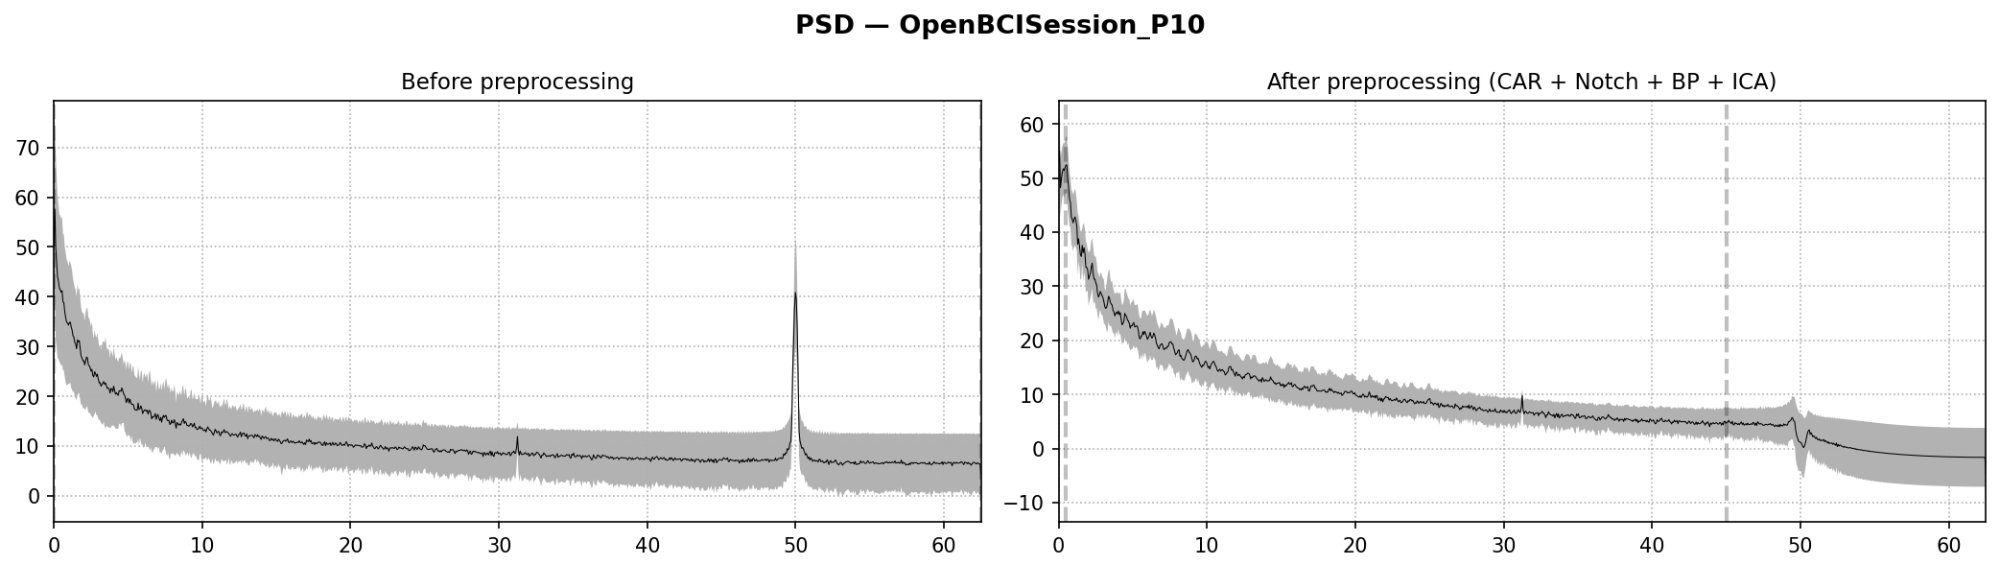

### 2.3 ICA + ICLabel — eliminación automática de artefactos

El Análisis de Componentes Independientes (ICA) descompone la señal EEG en fuentes estadísticamente independientes.
Algunas de estas fuentes son artefactos (parpadeos oculares, movimiento muscular, ruido de línea) y no actividad cerebral.
El ICA permite identificarlas y eliminarlas antes de reconstruir la señal.

**ICLabel** es un clasificador neuronal preentrenado que asigna a cada componente una probabilidad de pertenencia a 7 categorías:
`brain`, `eye blink`, `muscle artifact`, `heart`, `line noise`, `channel noise`, `other`.

**Umbrales de rechazo:**

| Categoría | Umbral | Razón |
|---|---|---|
| eye blink | p > 0.70 | Artefacto ocular común, bien identificado por ICLabel |
| muscle artifact | p > 0.70 | EMG contamina frecuencias beta y gamma |
| line noise | p > 0.70 | Residuo de red eléctrica no eliminado por el Notch |
| other | p > 0.80 | Umbral más alto — conservador para evitar rechazo excesivo |


In [ ]:
from mne.preprocessing import ICA
from mne_icalabel import label_components
import warnings

def run_ica(raw_filtered, random_state=42):
    """Aplica ICA + ICLabel y rechaza componentes artefactuales."""

    # n_components como fracción de varianza explicada
    # MNE calcula automáticamente cuántos componentes se necesitan
    ica = ICA(
        n_components=0.999999,
        method='infomax',
        fit_params=dict(extended=True),  # Extended Infomax: maneja fuentes sub- y super-gaussianas
        random_state=random_state,       # Semilla fija → reproducibilidad
        verbose=False
    )
    ica.fit(raw_filtered, verbose=False)

    # ICLabel clasifica cada componente
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ic_labels = label_components(raw_filtered, ica, method='iclabel')

    labels = ic_labels['labels']
    probs  = ic_labels['y_pred_proba']

    # Umbral de rechazo por categoría
    thresholds = {'eye blink': 0.70, 'muscle artifact': 0.70, 'line noise': 0.70, 'other': 0.80}

    exclude = []
    for i, (label, prob) in enumerate(zip(labels, probs)):
        if label in thresholds and prob > thresholds[label]:
            exclude.append(i)
            print(f'  Excluyendo IC {i:02d}: {label} (p={prob:.3f})')

    # Aplicar rechazo: los componentes excluidos se zeroed-out
    ica.exclude = exclude
    raw_clean = raw_filtered.copy()
    ica.apply(raw_clean, verbose=False)

    return raw_clean, {'labels': labels, 'excluded': exclude}

La figura siguiente muestra la clasificación ICLabel para el participante P3.
La línea punteada gris a p=0.70 indica el umbral de rechazo.
En este caso ningún componente superó el umbral (n=0 excluidos), lo que es coherente con una sesión de buena calidad de señal.
En sesiones con más artefactos, se observan componentes de eye blink o muscle artifact con probabilidades > 0.70.


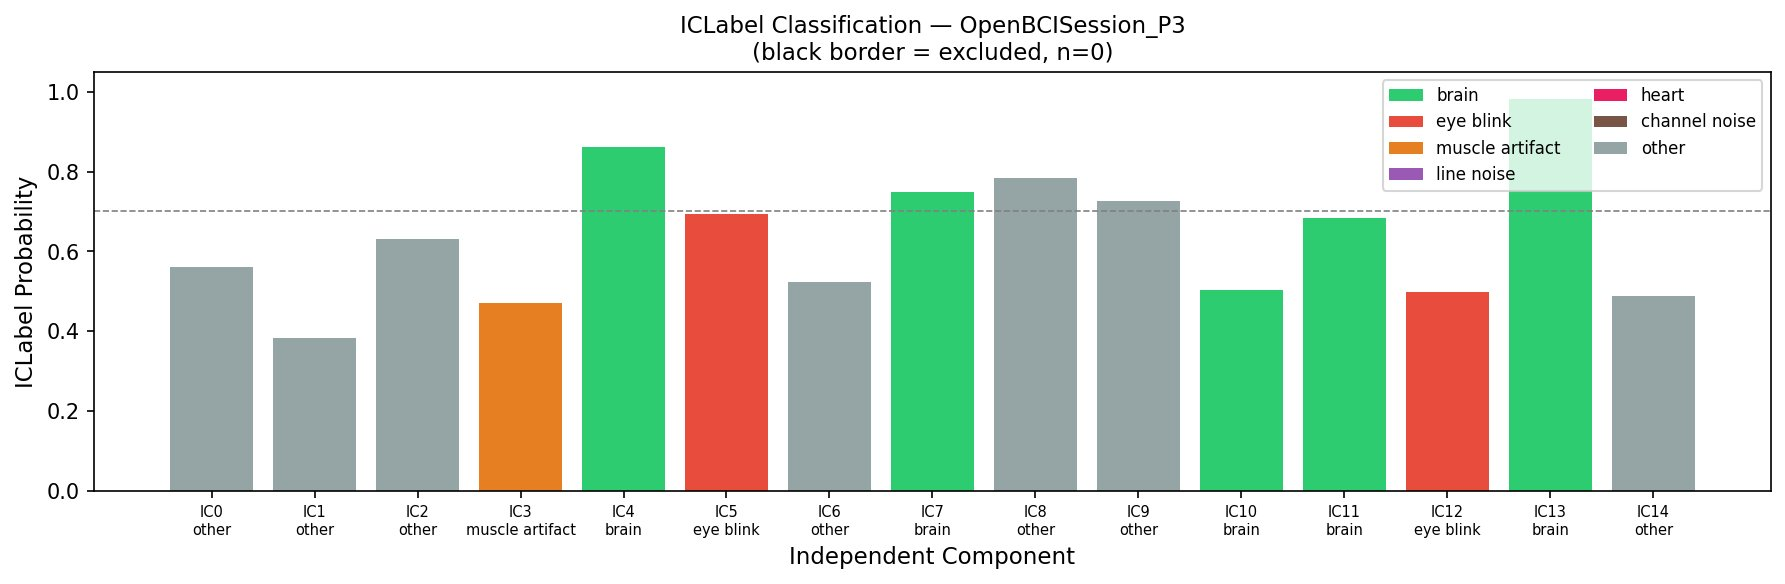

### 2.4 Exportación

Finalizado el pipeline, la señal limpia se re-asocia al vector de timestamps originales y se exporta como Parquet.


In [ ]:
def export_clean_dataframe(raw_clean, timestamps):
    """Exporta la señal EEG limpia como DataFrame con timestamps."""
    # Reconvertir de Voltios a µV para legibilidad
    data_uv = raw_clean.get_data() * 1e6  # shape: (16, n_muestras)

    df_clean = pd.DataFrame(data_uv.T, columns=raw_clean.ch_names)

    # Re-asociar timestamps originales (esencial para sincronización posterior)
    df_clean['timestamp'] = timestamps.values

    return df_clean  # shape: (n_muestras, 17) — 16 canales + timestamp

# Guardar
df_clean.to_parquet('data/processed/eeg/P1.parquet', index=False)

---
## 3. Preprocesamiento Tobii — GSR, Pupilometría y Eye Tracking

Las tres señales del Tobii Pro se procesan en el mismo pipeline porque comparten reloj hardware.
El pipeline sigue el orden: **reconstrucción de timestamps → resampleo a grilla uniforme → limpieza GSR → limpieza pupilar → extracción de eventos de eye tracking**.

### 3.1 Reconstrucción de timestamps

El Tobii Pro no expone un timestamp de pared utilizable directamente.
El archivo de exportación tiene tres columnas temporales que hay que combinar:


In [ ]:
def reconstruct_timestamps(df, date_format='%m/%d/%Y %H:%M:%S.%f'):
    """Reconstruye timestamps absolutos a partir de las columnas del Tobii."""

    df = df.copy()
    df['recording_datetime'] = pd.to_datetime(
        df['Recording date'] + ' ' + df['Recording start time'],
        format=date_format
    )
    # Formato de fecha es mm/dd/yyyy
    df['timestamp'] = (
        df['recording_datetime'] +
        pd.to_timedelta(df['Recording timestamp'], unit='us')  # microsegundos desde inicio
    )

    # Validación: el año debe ser > 2000 para asegurar que la reconstrucción fue correcta y no se interpretó como Unix epoch
    assert df['timestamp'].min().year > 2000, 'Error en reconstrucción de timestamps'

    return df

### 3.2 Resampleo a grilla uniforme de 60 Hz

El stream del Tobii Pro es **temporalmente irregular**: la frecuencia efectiva oscila entre 65–68 Hz, no los 60 Hz nominales.
Para poder alinear las señales y hacer slicing por eventos, se construye una grilla temporal uniforme de 60 Hz compartida por todas las señales del participante.

**Nota sobre la GSR:** el sensor GSR del Tobii captura a ~8 Hz efectivos dentro del stream de 60 Hz (~18% de muestras válidas).
Esto es estructural del sensor, no pérdida de datos. Las muestras válidas se interpolan sobre la grilla de 60 Hz.


In [ ]:
from scipy.interpolate import interp1d

def resample_to_uniform_grid(series, timestamps, uniform_index, gap_max_ms=200.0):
    """
    Resamplea una señal irregular a una grilla temporal uniforme.

    Gaps > gap_max_ms NO se interpolan → quedan como NaN en el output.
    Empíricamente: ~1 gap > 200 ms por sesión (despreciable).
    """
    t_start = uniform_index[0]

    valid_mask = series.notna()
    valid      = series[valid_mask]
    ts_valid   = timestamps[valid_mask.values]

    ts_seconds      = (ts_valid - t_start).dt.total_seconds().values
    uniform_seconds = (uniform_index - t_start).total_seconds().values

    interp_fn = interp1d(ts_seconds, valid.values,
                         kind='linear', bounds_error=False, fill_value=np.nan)
    resampled = interp_fn(uniform_seconds)

    # Preservar NaN en gaps grandes
    gap_threshold_s = gap_max_ms / 1000.0
    # [lógica de re-introducción de NaN para gaps grandes]

    return pd.Series(resampled, index=uniform_index)

# La grilla se construye UNA VEZ por participante y se comparte entre GSR y pupila
uniform_index = pd.date_range(start=t_start, end=t_end, freq='1/60s')  # 60 Hz

### 3.3 Preprocesamiento GSR

La señal de conductancia galvánica de la piel (GSR/EDA) contiene dos componentes fisiológicamente distintos:

- **SCL (Skin Conductance Level):** componente tónico — varía lentamente, refleja el nivel basal de activación simpática (arousal sostenido)
- **SCR (Skin Conductance Response):** componente fásico — picos rápidos ante estímulos específicos (reactividad simpática puntual)

In [ ]:
from scipy.stats import zscore

def clean_gsr(df, uniform_index, sigma_threshold=5.0):
    """Pipeline completo de limpieza GSR."""

    gsr_raw = df['Galvanic skin response (GSR)']

    # 1. Detección de artefactos por salto abrupto (desconexión del sensor)
    # Umbral adaptativo: mean + 5*std de la derivada absoluta
    delta = gsr_raw.diff().abs()
    threshold = delta.mean() + sigma_threshold * delta.std()
    gsr_clean = gsr_raw.where(delta <= threshold)  # artefactos → NaN

    # 2. Resampleo a grilla uniforme de 60 Hz
    gsr_resampled = resample_to_uniform_grid(gsr_clean, df['timestamp'], uniform_index)

    # 3. Descomposición SCL/SCR con cvxEDA
    import cvxeda
    valid_samples = gsr_resampled.dropna().values
    [r, p, tonic, phasic, _, _, _] = cvxeda.cvxeda(valid_samples, 1/60.0)

    # 4. Normalización z-score por sujeto
    # Controla diferencias inter-individuo en conductividad basal
    gsr_norm = (gsr_resampled - gsr_resampled.mean()) / gsr_resampled.std()

    # Resultado: scl (tónico) y scr (fásico)
    return {'gsr_norm': gsr_norm, 'scl': tonic, 'scr': phasic}

Acá es importante notar que descomposición tónico-fásica va antes que el z-score, esto es pues el algoritmo de cvxEDA formula la descomposicion de la conductancia sujeto a la restricción de que los impulsos del nervio sudomotor no pueden ser negativos. Luego al aplicar z-score la señal de centra en 0 introduciendo valores negativos i.e debe ir despues

La figura siguiente muestra la señal GSR del participante P3 con sus dos componentes descompuestos por cvxEDA:

- **Panel superior:** señal GSR normalizada (z-score). Los picos abrupos en ~08:15:23 corresponden a artefactos detectados.
- **Panel central (verde):** componente tónico (SCL) — varía lentamente, representa el nivel de arousal sostenido durante la sesión.
- **Panel inferior (rojo):** componente fásico (SCR) — picos rápidos ante eventos específicos. Los picos más pronunciados en ~08:15:24–08:15:30 corresponden a respuestas simpáticas ante estímulos de alta activación.


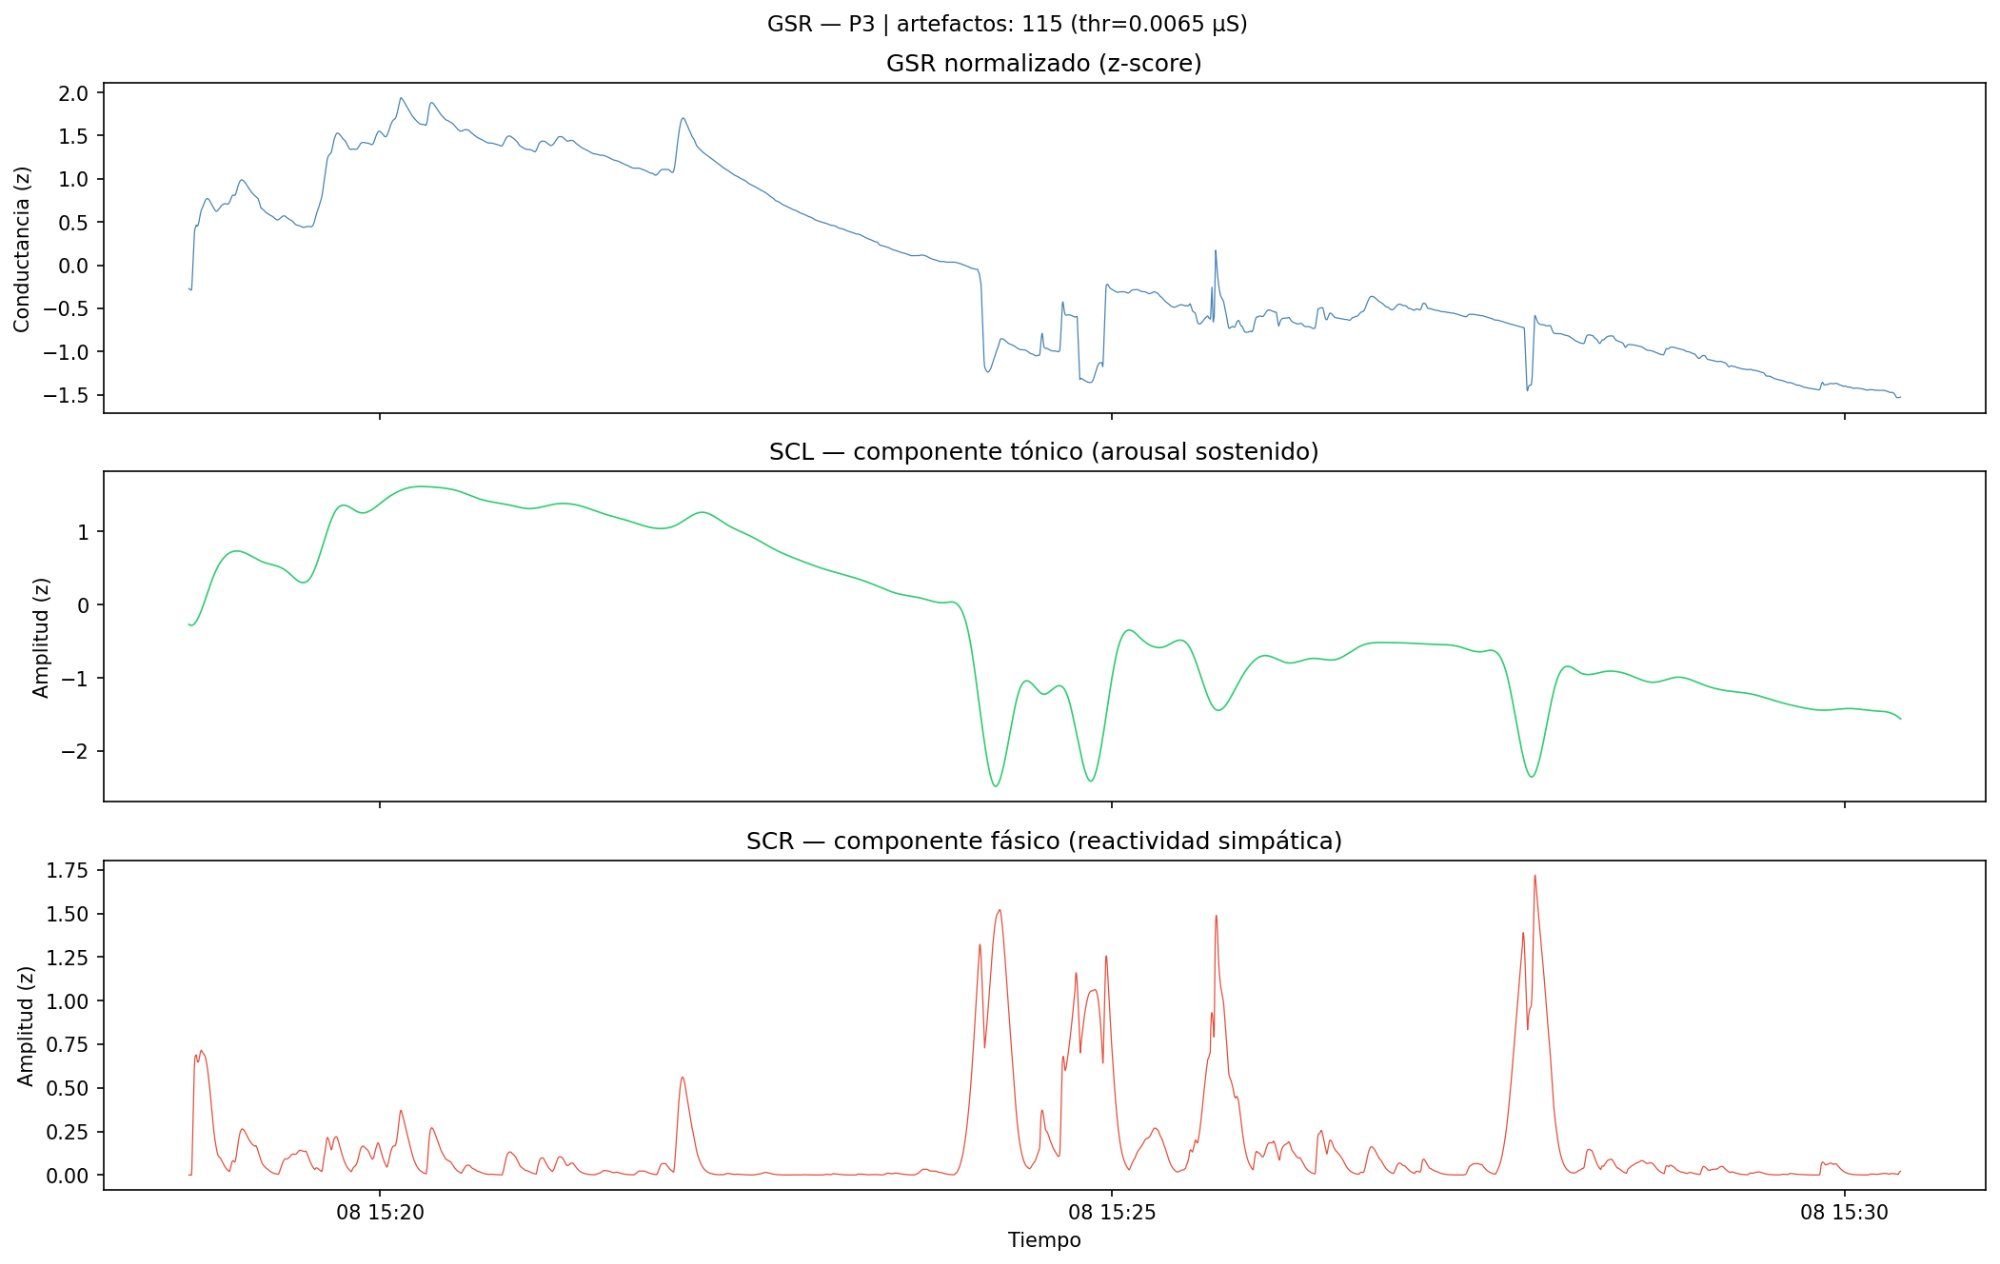

### 3.4 Preprocesamiento pupilar

El diámetro pupilar varía por dos razones simultáneas: (1) cambios en la iluminación (reflejo pupilar luminoso) y (2) carga cognitiva y arousal emocional.
El pipeline actual elimina los artefactos de parpadeo e interpola las ventanas afectadas.

**Nota:** la corrección luminosa (para disociar respuesta cognitiva de reflejo lumínico) no está implementada en la versión actual del pipeline.
Queda como tarea pendiente antes de usar el diámetro pupilar como proxy de carga cognitiva en el feature engineering.


In [ ]:
def clean_pupil(df, uniform_index, blink_threshold=0.30):
    """Pipeline de limpieza de la señal pupilar."""

    # Señal principal: 'Pupil diameter filtered' (ya suavizado por Tobii)
    # Fallback: diámetro izquierdo si filtered no está disponible
    pupil = df['Pupil diameter filtered'].copy()

    # 1. Detección de parpadeos
    # Un parpadeo produce una caída abrupta del diámetro pupilar
    # Detectamos como parpadeo si la variación porcentual > 30%
    pct_change = pupil.pct_change().abs()
    blink_mask = pct_change > blink_threshold
    pupil_with_nan = pupil.where(~blink_mask)  # parpadeos → NaN

    # 2. Interpolación cúbica en ventanas de parpadeo
    # Se prefiere cúbica sobre lineal porque preserva continuidad de la 1ª y 2ª derivada
    # reproduciendo la dinámica suave de la dilatación pupilar
    pupil_interpolated = pupil_with_nan.interpolate(method='cubic')

    # 3. Resampleo a grilla uniforme de 60 Hz
    pupil_resampled = resample_to_uniform_grid(pupil_interpolated, df['timestamp'], uniform_index)

    # 4. Normalización z-score por sujeto
    pupil_norm = (pupil_resampled - pupil_resampled.mean()) / pupil_resampled.std()

    n_blinks = blink_mask.sum()
    pct_blinks = 100 * n_blinks / len(pupil)
    print(f'  Parpadeos detectados: {n_blinks} ({pct_blinks:.2f}%)')

    return {'pupil_raw': pupil_resampled, 'pupil_clean': pupil_norm, 'n_blinks': n_blinks}

La figura siguiente muestra la señal pupilar del participante P4:

- **Panel superior:** señal raw (mm) con los 9 parpadeos detectados marcados en rojo. Se observan caídas abruptas del diámetro.
- **Panel inferior:** señal post-interpolación y normalización z-score. Las ventanas de parpadeo están reconstruidas con spline cúbico.


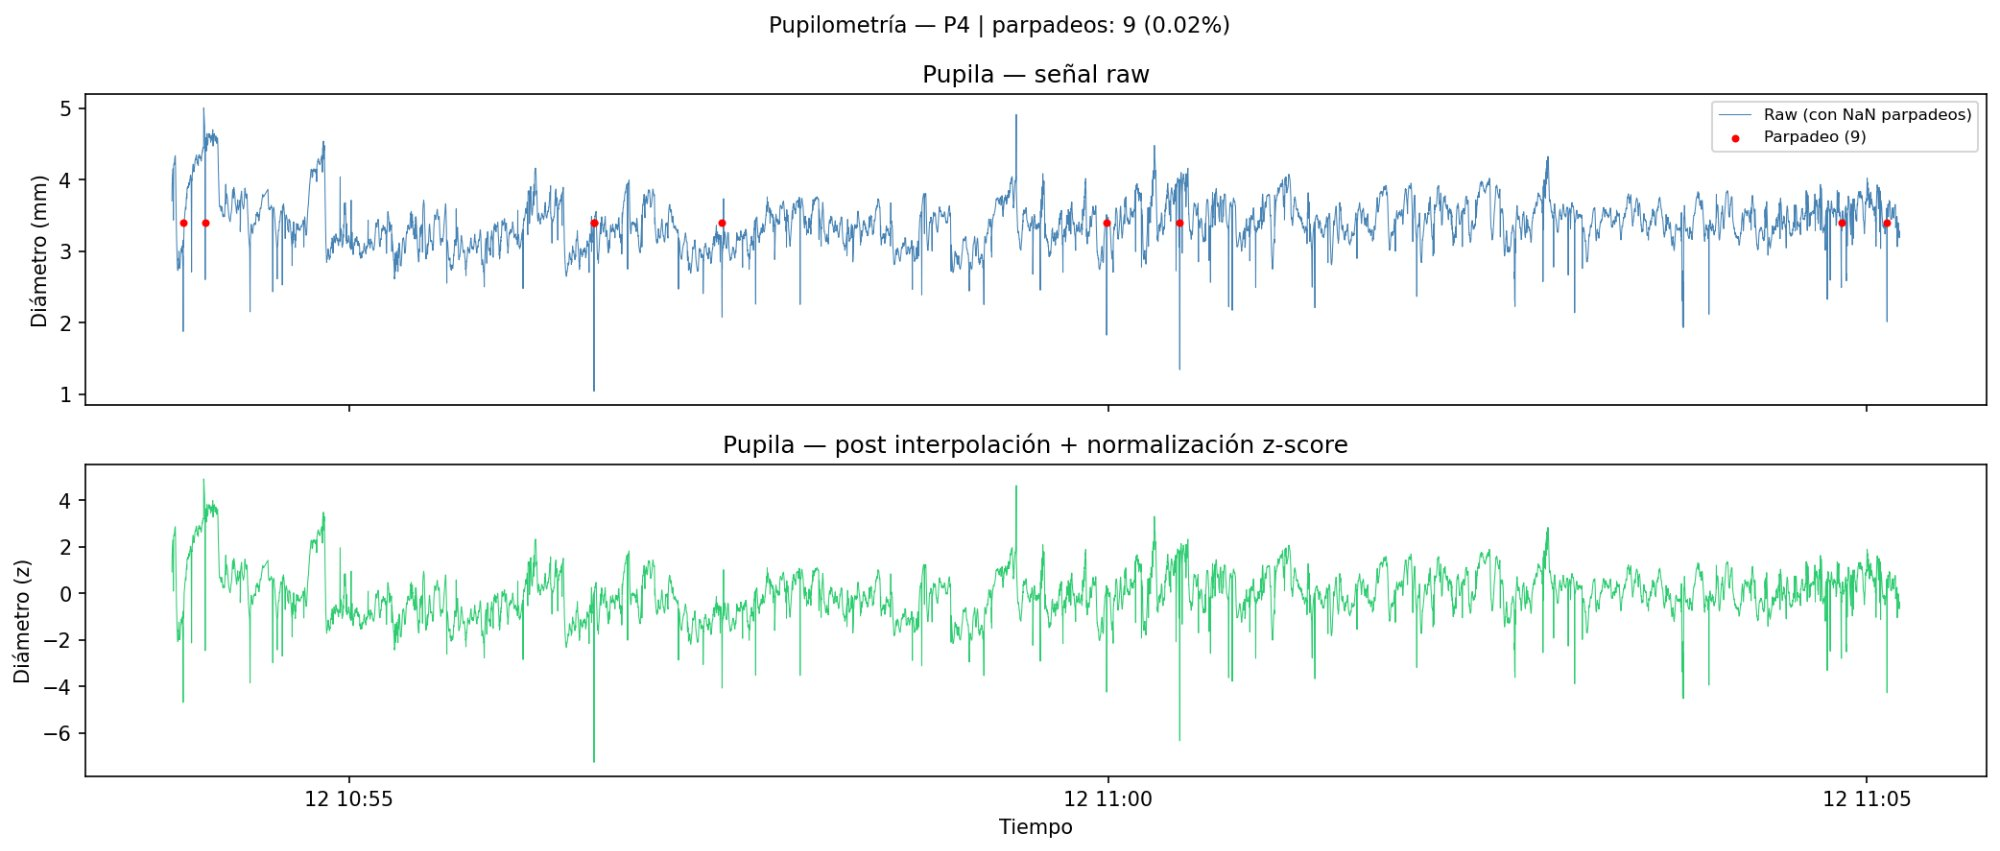

### 3.5 Extracción de eventos de Eye Tracking

El Tobii Pro aplica internamente el algoritmo I-VT (Velocity-Threshold Identification) para clasificar cada muestra en:
`Fixation`, `Saccade`, `EyesNotFound` o `Unclassified`.
El pipeline extrae resúmenes estadísticos a nivel de evento sin recalcular la clasificación.


In [ ]:
def extract_eye_tracking(df, min_fixation_ms=100.0):
    """Extrae fijaciones y sacadas desde la clasificación I-VT del Tobii."""

    # Fijaciones: agregadas por evento (Eye movement type index)
    fixations_raw = df[df['Eye movement type'] == 'Fixation']
    fixations = (
        fixations_raw
        .groupby('Eye movement type index')
        .agg(
            onset    = ('timestamp', 'min'),
            duration = ('Gaze event duration', 'first'),  # ms
            x        = ('Fixation point X', 'mean'),
            y        = ('Fixation point Y', 'mean'),
        )
        .reset_index(drop=True)
    )

    # Filtrar fijaciones < 100 ms — inestabilidades del tracker
    fixations = fixations[fixations['duration'] >= min_fixation_ms]

    # Sacadas: misma lógica
    saccades_raw = df[df['Eye movement type'] == 'Saccade']
    saccades = (
        saccades_raw
        .groupby('Eye movement type index')
        .agg(onset=('timestamp','min'), duration=('Gaze event duration','first'))
        .reset_index(drop=True)
    )

    return {'fixations': fixations, 'saccades': saccades}

# Los DataFrames de fijaciones y sacadas se guardan en Parquet separados:
# data/processed/tobii/P1_fixations.parquet
# data/processed/tobii/P1_saccades.parquet

La figura siguiente muestra el resumen de eye tracking del participante P7:

- **Panel izquierdo:** distribución de duraciones de fijación (percentil 99). Mediana de 200 ms — dentro del rango típico de 200–300 ms reportado en la literatura para estímulos web.
- **Panel derecho:** mapa de densidad hexagonal de los puntos de fijación. Se observa mayor densidad en la zona central-superior de la pantalla, coherente con una estrategia de exploración top-down típica en páginas web.


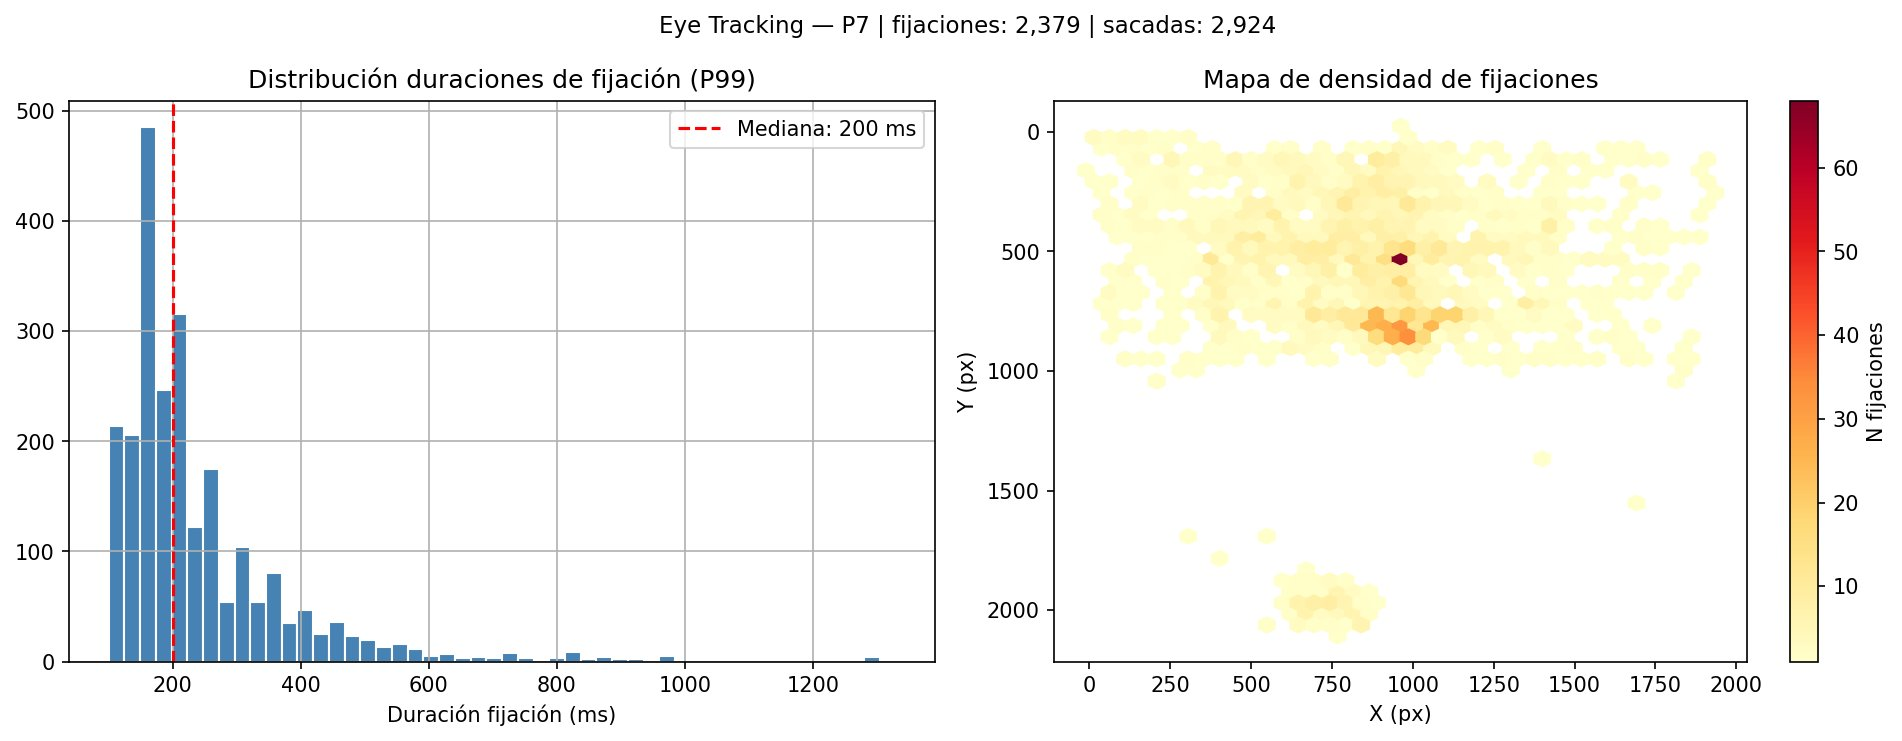

---
## 4. Sincronización EEG ↔ Tobii

### El problema: Osciladores de Hardware Independientes

El EEG (OpenBCI) y el Tobii Pro operan sobre **cristales de cuarzo independientes**, introduciendo dos fenómenos de desalineación:

1. **Offset inicial:** El operador activa el EEG antes que el Tobii (~20–60 s de diferencia). Este desfase físico es **absorbido de forma nativa** al reconstruir ambas series temporales sobre el Reloj Absoluto del Sistema Operativo (`datetime64`), el cual actúa como hiperplano temporal compartido.
2. **Drift de reloj:** Los osciladores difieren ligeramente en su frecuencia física. Esta divergencia se acumula linealmente durante la sesión (~0.1–0.8 ms/min). Si no se corrige el vector temporal, los epochs de 10 segundos terminarán desfasados respecto a los estímulos hacia el final de la sesión.

### La solución: Proyección Afín sobre el Reloj de Sistema

Dado que el sistema EEG es "ciego" a los estímulos experimentales (no recibe *triggers* por hardware), los eventos `ImageStimulusStart` quedan registrados **exclusivamente en el archivo de Tobii**.

Sin embargo, al reconstruir los timestamps de ambas modalidades utilizando el Reloj del Sistema Operativo (`datetime64`), el OS-RTC actúa como un "puente" temporal. Utilizamos las marcas de tiempo absolutas de los estímulos registrados por Tobii para buscar las latencias exactas en la señal continua del EEG.

Como el *offset* inicial ya está resuelto implícitamente por el origen del `datetime64`, la sincronización se reduce a una **transformación afín pura**: calculamos un escalado lineal ($s_{drift}$) comparando el tiempo transcurrido entre el primer y último estímulo según Tobii ($D_{tobii}$), versus el tiempo transcurrido en las muestras equivalentes del EEG ($D_{eeg}$). Este factor corrige la divergencia de los cuarzos sin alterar las frecuencias de muestreo nativas (125 Hz y 60 Hz).

In [ ]:
def compute_sync_params(eeg_df, tobii_df, events_df, anchor_event='ImageStimulusStart'):
    """Estima offset inicial y factor de escala por drift."""

    eeg_start   = eeg_df['timestamp'].iloc[0]
    tobii_start = tobii_df['timestamp'].iloc[0]

    # 1. Offset inicial: diferencia en el origen de ambos relojes (solo informativo)
    offset_s = (tobii_start - eeg_start).total_seconds()
    # P1: offset = +47.166 s (EEG empieza antes que Tobii — normal)

    # 2. Factor de escala por drift
    # Comparar el intervalo entre primer y último anchor event
    anchors_os = events_df[events_df['event'] == anchor_event]['timestamp']

    D_tobii = (anchors_os.iloc[-1] - anchors_os.iloc[0]).total_seconds()

    # Buscar los mismos eventos directamente en el espacio temporal absoluto del EEG
    idx_first = (eeg_df['timestamp'] - anchors_os.iloc[0]).abs().idxmin()
    idx_last  = (eeg_df['timestamp'] - anchors_os.iloc[-1]).abs().idxmin()

    D_eeg = (eeg_df['timestamp'].iloc[idx_last] - eeg_df['timestamp'].iloc[idx_first]).total_seconds()

    sdrift = D_tobii / D_eeg
    drift_ms = (sdrift - 1) * D_tobii * 1000

    print(f'Offset: {offset_s:.3f} s  |  Drift: {drift_ms:.2f} ms  |  Scale: {sdrift:.8f}')
    # P1: Offset: 47.166 s  |  Drift: −2.90 ms  |  Scale: 1.00000441

    return {'offset_s': offset_s, 'drift_scale': sdrift, 'drift_ms': drift_ms, 'eeg_start': eeg_start}

In [ ]:
def correct_eeg_timestamps(eeg_df, sync_params):
    """
    Proyecta los timestamps EEG aplicando la corrección de drift.

    Mantiene el intercepto original (eeg_start) ya que ambos sistemas
    comparten el mismo reloj.
    """
    eeg_start = sync_params['eeg_start']
    sdrift    = sync_params['drift_scale']

    # Transformación afín: mantiene el origen y aplica escala de drift
    eeg_df['timestamp_corrected'] = (
        eeg_start +
        pd.to_timedelta(
            (eeg_df['timestamp'] - eeg_start).dt.total_seconds() * sdrift,
            unit='s'
        )
    )

    return eeg_df

# A partir de aquí:
# - Slicing EEG → usar 'timestamp_corrected'
# - Slicing Tobii → usar la grilla uniforme de 60 Hz ('timestamp')
# Ambos están exactamente en el mismo dominio temporal absoluto

La figura siguiente muestra la distribución del drift acumulado para todos los participantes de la cohorte (n=47).
**Ningún participante supera el umbral de ±50 ms** (líneas punteadas rojas), lo que valida que la corrección lineal es suficiente
para todo el dataset WIC — no se requieren modelos de corrección de orden superior.

El panel derecho muestra que no hay tendencia sistemática en la tasa de drift entre participantes,
confirmando la estabilidad de los osciladores hardware.


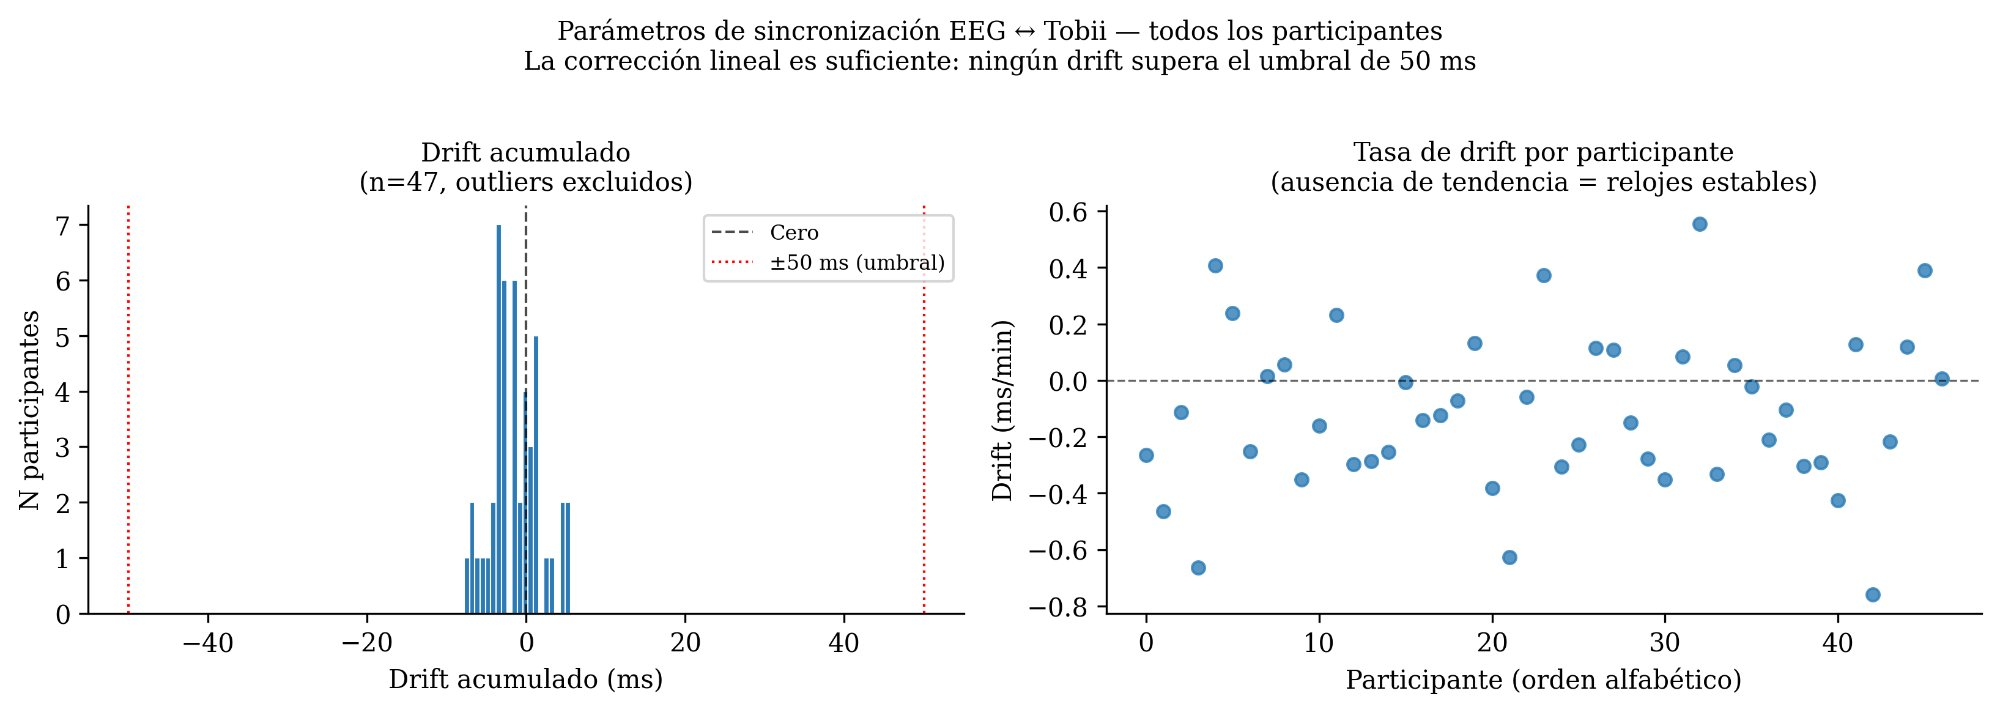

### 4.1 Taxonomía de estímulos y segmentación de epochs

El protocolo experimental expone a los participantes a estímulos de distinto tipo durante la sesión.
No todos son relevantes para el entrenamiento de los modelos:

| Tipo | Regla | Uso |
|---|---|---|
| `exposicion_imagen` | Nombre de estímulo numérico puro (ej: `'6'`, `'14'`) | **Entrada principal** — conjunto de entrenamiento |
| `blur_exposicion` | Prefijo `blur_` | Excluir — imagen de transición entre estímulos |
| `evaluacion_imagen` | Prefijo `diseño_` o `emotion_` | Excluir — pantalla de calificación subjetiva post-estímulo |
| `evaluacion_web` | Post-WebStimulusEnd | Excluir — evaluación web |
| `web_sitio` | WebStimulusStart → End | Navegación libre (uso futuro) |
| `web_url` | URLStart → End | Página individual (uso futuro) |

La figura siguiente muestra la estructura temporal del experimento para el participante P9.
Los fondos coloreados delimitan las cuatro fases. Los marcadores sobre el eje horizontal representan eventos `ImageStimulusStart`, codificados por tipo.


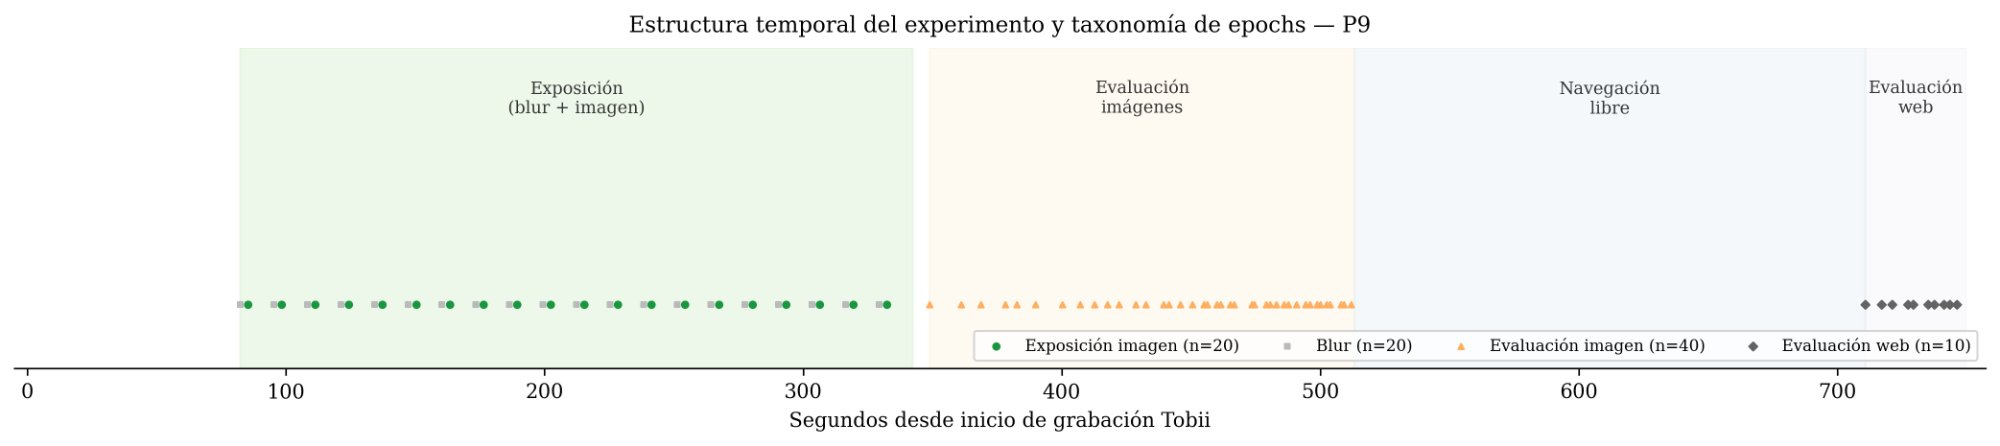

In [ ]:
def extract_epochs(eeg_df, tobii_df, stimuli, tmin=-0.2, tmax_offset=0.5):
    """
    Extrae epochs sincronizados EEG + Tobii para cada estímulo.

    Ventana: [onset + tmin,  onset + duration + tmax_offset]
    tmin = -0.2 s → baseline pre-estímulo
    tmax_offset = +0.5 s → margen post-offset
    """
    epochs = []
    for _, stim in stimuli.iterrows():
        # El onset es el timestamp absoluto del OS
        onset    = stim['timestamp_start']
        duration = stim['duration_s']

        t_start = onset + pd.Timedelta(seconds=tmin)
        t_end   = onset + pd.Timedelta(seconds=duration + tmax_offset)

        # Slicing EEG → usar timestamp_corrected (estirado por drift)
        eeg_epoch = eeg_df[
            (eeg_df['timestamp_corrected'] >= t_start) &
            (eeg_df['timestamp_corrected'] < t_end)
        ]

        # Slicing Tobii → usar la grilla uniforme de 60 Hz
        tobii_epoch = tobii_df[
            (tobii_df['timestamp'] >= t_start) &
            (tobii_df['timestamp'] < t_end)
        ]

        epochs.append({
            'stimulus_id': stim['name'] if 'name' in stim else stim['stimulus'],
            'eeg':   eeg_epoch[ch_names].values,    # shape: (T_eeg, 16)
            'gsr':   tobii_epoch['scr'].values,      # shape: (T_tobii,)
            'pupil': tobii_epoch['pupil_clean'].values,  # shape: (T_tobii,)
        })

    return epochs

# Para un estímulo de 10 s:
# T_eeg   = 1337 muestras (125 Hz × 10.7 s con márgenes)
# T_tobii =  642 muestras (60 Hz × 10.7 s con márgenes)
# Ratio: 1337/642 ≈ 2.083 = 125/60 ✓

La figura siguiente muestra un epoch sincronizado del participante P9 (estímulo '6', tipo `exposicion_imagen`).
Los tres paneles comparten el mismo eje temporal (segundos desde onset del estímulo, línea punteada en t=0):

- **Panel superior (EEG, 125 Hz):** 16 canales en gris claro. Los canales **F3 y F4** resaltados en azul como proxy del FAA (Frontal Alpha Asymmetry).
- **Panel central (GSR, 60 Hz):** componente GSR normalizado. Se observa una respuesta de conductancia que comienza ~4 s post-onset — coherente con la latencia típica de las SCR (1–5 s).
- **Panel inferior (Pupilometría, 60 Hz):** diámetro pupilar limpio, normalizado z-score. La diferencia en densidad de puntos entre los paneles EEG y Tobii refleja la relación de frecuencias 125/60 ≈ 2.08 — intencional.


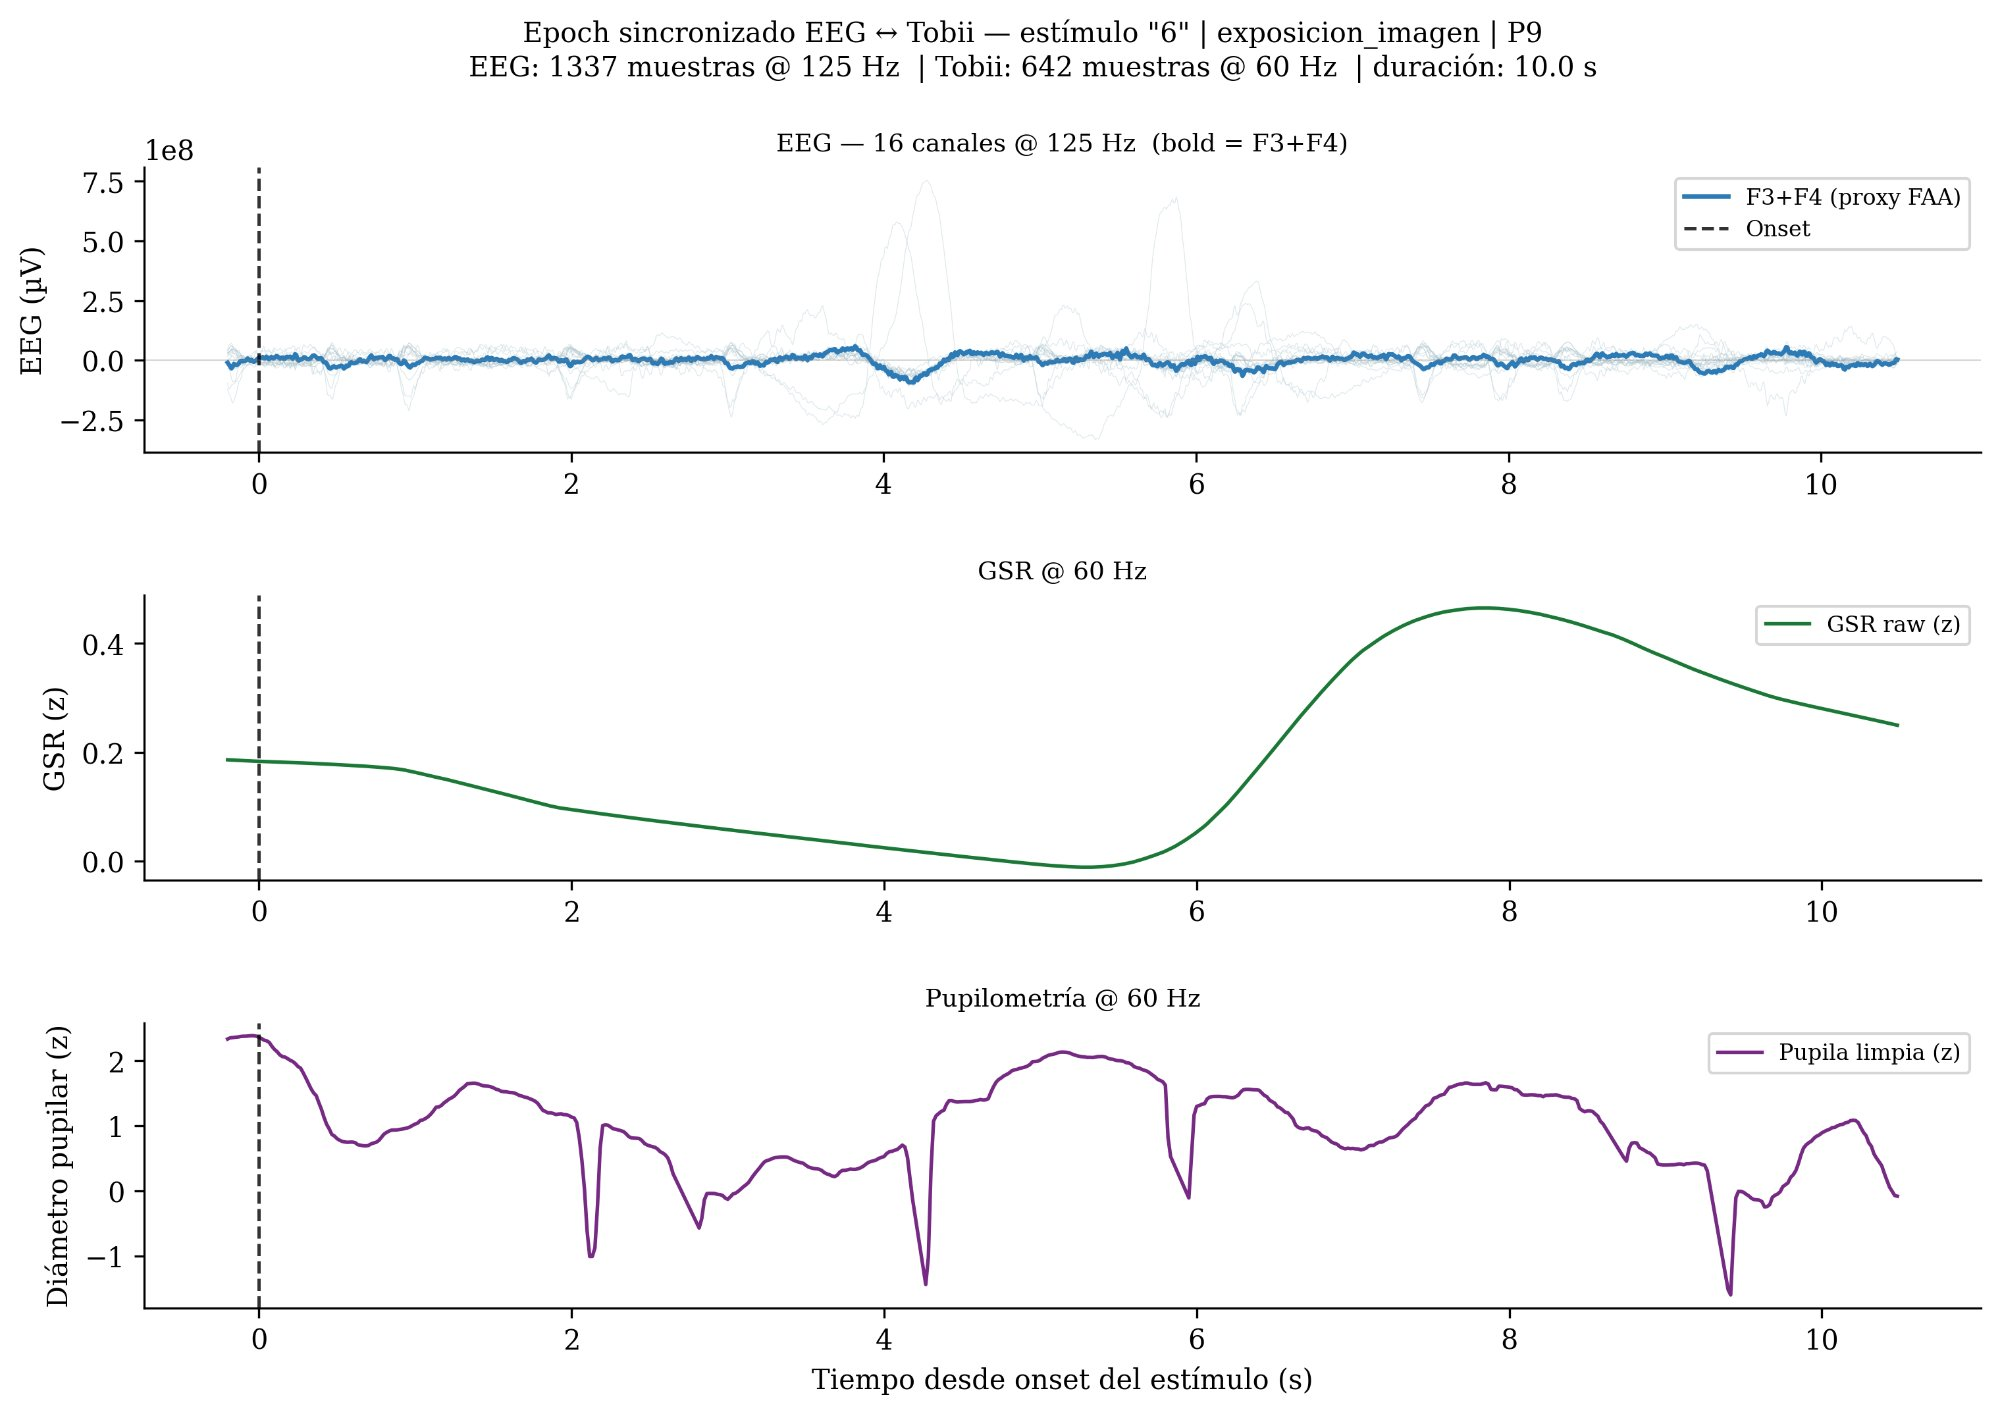